In [45]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns 

import jax
import jax.numpy as jnp
import jax.scipy.stats as stats
import jax.random as jr
from jax.scipy.special import logsumexp
from functools import partial


In [46]:
num_integration_steps = 10   # must stay even, per your earlier assumption
step_size = 0.1
num_overall_steps = 100000
burn_in = 100
num_dimensions = 2
start_position = jnp.array([0.0, 0.0])
start_momentum = jnp.array([0.0, 0.0])

rng = jax.random.PRNGKey(10)  # replace with your preferred seed
alpha = 1
# This is equivalently V(q) or V(x)

#inv_mass_matrix = jnp.array([[ 0.30757812, -0.24073476],
#[-0.24073476,  0.30670038]])
inv_mass_matrix = jnp.array([[1.0, 0.0], 
                             [0.0, 1.0]])
mass_matrix = jnp.linalg.inv(inv_mass_matrix)
prior_cov_matrix = jnp.array([[1.0, 0],
                       [0, 1.0]])
measurement_error_bar = 0.1;

# Measurement: e^x + e^y = 1 +\- 0.1
#x is a VECTOR
def negative_logdensity(x):
    log_P_data_given_signal = 0.5*((jnp.sum(jnp.exp(x)) - 1)/measurement_error_bar)**2;
    log_P_signal =  0.5*x.T @ jnp.linalg.inv(prior_cov_matrix) @ x; 
    return log_P_data_given_signal + log_P_signal;
# in the future, only JITing the computationally expensive gradient is the most important 
negative_logdensity_grad = jax.jit(jax.grad(negative_logdensity))





In [47]:
@jax.jit
def one_leapfrog_step(position, momentum, dt, momentum_scale_factor):
    #jax.debug.print("position = {p}, negativelogdensitygrad = {x}", p=position, x = negative_logdensity_grad(position))
    momentum = momentum - 0.5*dt*negative_logdensity_grad(position)
    momentum *= momentum_scale_factor
    position = position + dt * (inv_mass_matrix @ momentum)
    momentum = momentum - 0.5*dt*negative_logdensity_grad(position)
    momentum *= momentum_scale_factor
    return position, momentum



In [48]:
# Precompute once, outside the hot path — mass_matrix doesn't change
mass_matrix_chol = jnp.linalg.cholesky(mass_matrix)

def leapfrog_scan_body(carry, scale):
    position, momentum = carry
    position, momentum = one_leapfrog_step(position, momentum, step_size, scale)
    return (position, momentum), (position, momentum)


def one_overall_step(position, momentum, rng):
    initial_position = position
    initial_momentum_key, accept_key, rng = jax.random.split(rng, 3)
    momentum = mass_matrix_chol @ jax.random.normal(initial_momentum_key, shape=(num_dimensions,))
    initial_momentum = momentum
    initial_H = negative_logdensity(initial_position) + 0.5 * initial_momentum @ inv_mass_matrix @ initial_momentum

    half = num_integration_steps // 2
    scales = jnp.where(jnp.arange(num_integration_steps) < half, alpha, 1.0 / alpha)

    (position, momentum), (position_traj, momentum_traj) = jax.lax.scan(
        leapfrog_scan_body, (position, momentum), scales
    )

    final_H = negative_logdensity(position) + 0.5 * momentum @ inv_mass_matrix @ momentum
    acceptance_probability = jnp.minimum(1.0, jnp.exp(initial_H - final_H))
    real_acceptance_probability = jnp.where(jnp.isnan(acceptance_probability), 0.0, acceptance_probability)
    accept = jax.random.uniform(accept_key, shape=()) <= real_acceptance_probability
    position = jnp.where(accept, position, initial_position)
    momentum = jnp.where(accept, momentum, initial_momentum)

    return position, momentum, position_traj, momentum_traj, real_acceptance_probability, rng


In [49]:

def sampling_scan_body(carry, _):
    position, momentum, rng = carry
    position, momentum, pos_traj, mom_traj, accept_prob, rng = one_overall_step(position, momentum, rng)
    return (position, momentum, rng), (position, momentum, accept_prob)

@partial(jax.jit, static_argnames=('num_samples',))
def run_hmc(position, momentum, rng, num_samples):
    (final_position, final_momentum, final_rng), (positions, momenta, accept_probs) = jax.lax.scan(
        sampling_scan_body, (position, momentum, rng), None, length=num_samples
    )
    return final_position, final_momentum, final_rng, positions, momenta, accept_probs

final_position, final_momentum, rng, overall_position_arr, overall_momentum_arr, accept_prob_arr = run_hmc(
    start_position, start_momentum, rng, num_overall_steps
)

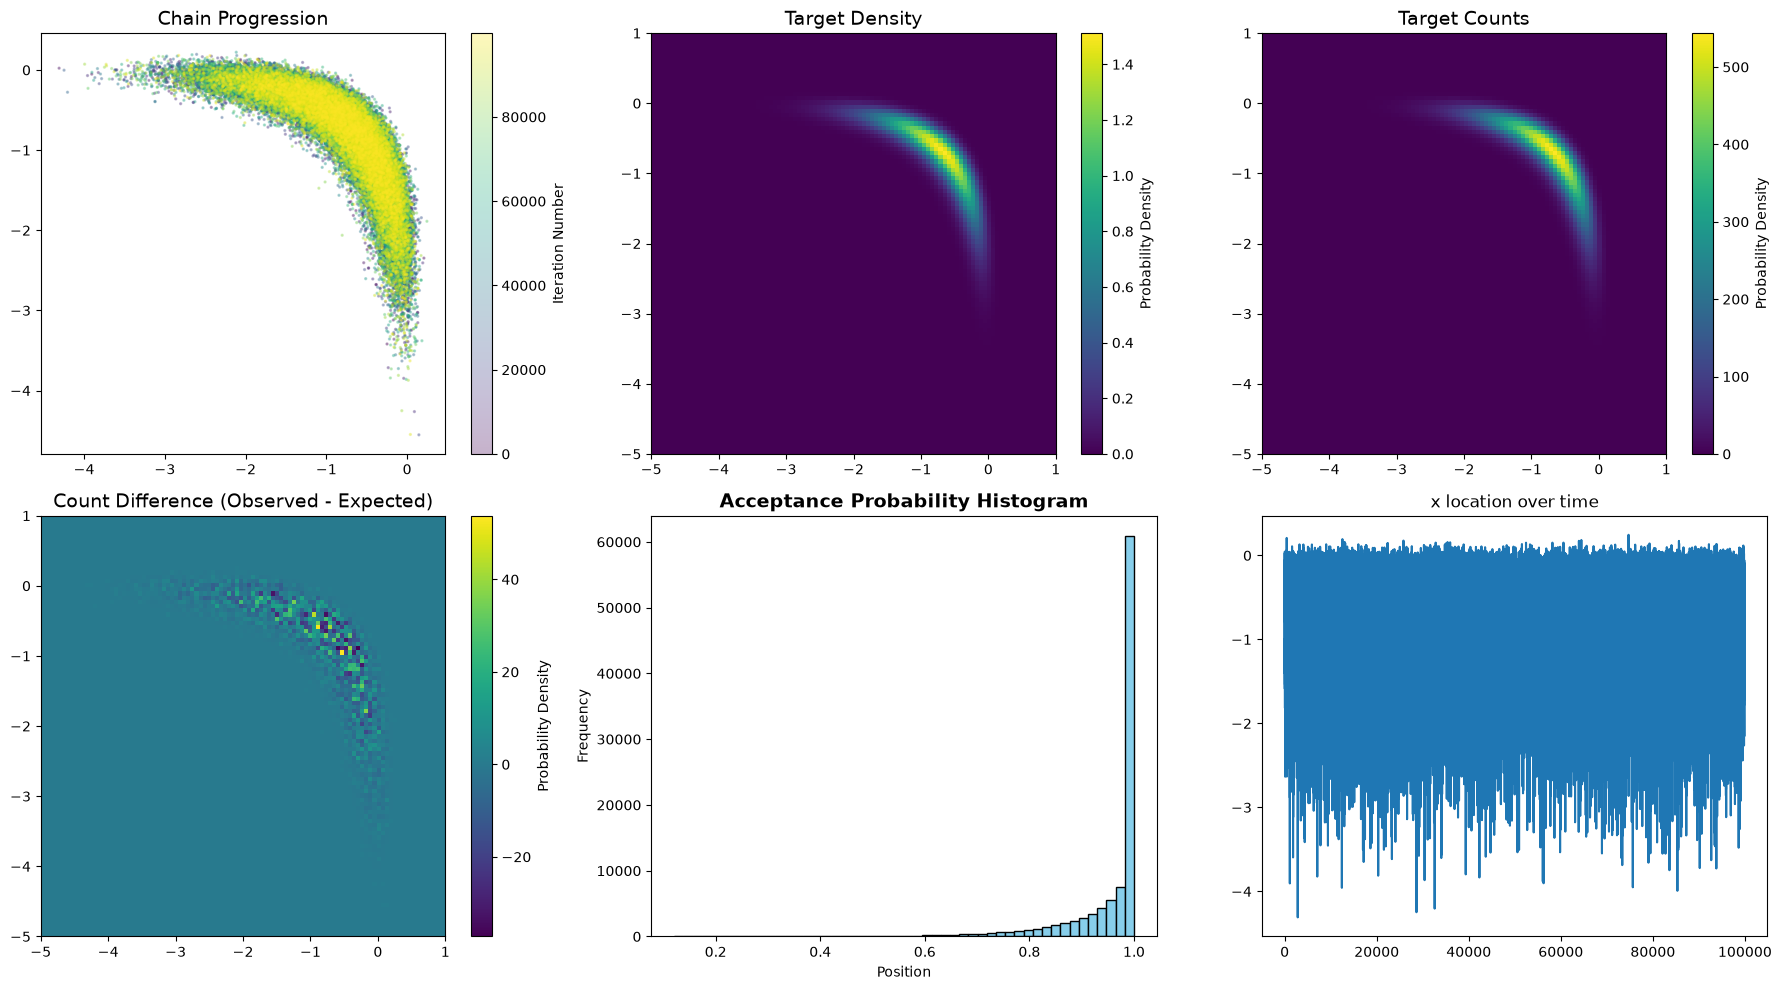

[[ 0.30757812 -0.24073476]
 [-0.24073476  0.30670038]]
KL_divergence is 0.0031415000557899475


In [50]:
overall_position_arr = overall_position_arr[burn_in:, :]
overall_momentum_arr = overall_momentum_arr[burn_in:, :]
accept_prob_arr = accept_prob_arr[burn_in:]
num_good_samples = num_overall_steps - burn_in

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

n_cells = 100          # number of rectangles per axis
k = 10               # sub-samples per axis per cell (k*k samples per cell)

# cell *edges*, not centers — n_cells rectangles need n_cells+1 boundary points
x_edges = jnp.linspace(-5, 1, n_cells + 1)
y_edges = jnp.linspace(-5, 1, n_cells + 1)
dx = x_edges[1] - x_edges[0]
dy = y_edges[1] - y_edges[0]

# midpoint-rule offsets within a cell, in (0, 1)
offsets = (jnp.arange(k) + 0.5) / k

# fine grid coords: for every cell, k points spread across its interior
x_fine = (x_edges[:-1, None] + offsets[None, :] * dx).ravel()  # shape (n_cells*k,)
y_fine = (y_edges[:-1, None] + offsets[None, :] * dy).ravel()

Xf, Yf = jnp.meshgrid(x_fine, y_fine)
pos_fine = jnp.stack([Xf.ravel(), Yf.ravel()], axis=-1)

Z_fine = jax.vmap(negative_logdensity)(pos_fine)
Z_fine = jnp.exp(-Z_fine).reshape(Xf.shape)          # shape (n_cells*k, n_cells*k)

# block-average: group each k x k sub-block back into one cell and mean it
Z_avg = Z_fine.reshape(n_cells, k, n_cells, k).mean(axis=(1, 3))  # shape (n_cells, n_cells)


total_prob_density = jnp.sum(Z_avg)*0.06**2;
normalized_density = Z_avg/total_prob_density
expected_bin_prob = normalized_density*0.06**2
expected_counts = expected_bin_prob*num_good_samples
observed_counts = jnp.zeros(Z_avg.shape)
x_values = jnp.floor((overall_position_arr[:, 0] + 5) * 100 / 6.0).astype(int)
y_values = jnp.floor((overall_position_arr[:, 1] + 5) * 100 / 6.0).astype(int)
observed_counts = observed_counts.at[y_values, x_values].add(1)
observed_bin_prob = observed_counts/num_good_samples

trial_space = jnp.arange(num_overall_steps)
iterations = np.arange(len(overall_position_arr))

scatter2 = axes[0][0].scatter(overall_position_arr[:, 0], overall_position_arr[:, 1], 
                           c=iterations, cmap='viridis', alpha=0.3, s=2)
axes[0][0].set_title("Chain Progression", fontsize=14)
# For colorbars in subplots, you must tell it which axis to attach to
fig.colorbar(scatter2, ax=axes[0][0], label="Iteration Number") 

heatmap = axes[0][1].imshow(normalized_density, extent=[-5, 1, -5, 1], origin='lower', cmap='viridis', aspect='auto')
axes[0][1].set_title("Target Density", fontsize = 14)
# Add a colorbar, labels, and title
fig.colorbar(heatmap, ax=axes[0][1], label='Probability Density')

heatmap = axes[0][2].imshow(expected_counts, extent=[-5, 1, -5, 1], origin='lower', cmap='viridis', aspect='auto')
axes[0][2].set_title("Target Counts", fontsize = 14)
# Add a colorbar, labels, and title
fig.colorbar(heatmap, ax=axes[0][2], label='Probability Density')

heatmap = axes[1][0].imshow(observed_counts - expected_counts, extent=[-5, 1, -5, 1], origin='lower', cmap='viridis', aspect='auto')
axes[1][0].set_title("Count Difference (Observed - Expected)", fontsize = 14)
# Add a colorbar, labels, and title
fig.colorbar(heatmap, ax=axes[1][0], label='Probability Density')

axes[1][1].hist(accept_prob_arr, bins=50, edgecolor='black', color='skyblue')

# Add labels and a title to make it readable
axes[1][1].set_title('Acceptance Probability Histogram', fontsize=14, fontweight='bold')
axes[1][1].set_xlabel('Position')
axes[1][1].set_ylabel('Frequency')

axes[1][2].plot(iterations, overall_position_arr[:, 0])
axes[1][2].set_title("x location over time")

plt.tight_layout()
plt.show()

def KL_divergence(expected_probs, observed_probs, jitter):
    usable_expected_probs = jnp.where(expected_probs == 0, jitter, expected_probs)
    usable_observed_probs = jnp.where(observed_probs == 0, jitter, observed_probs)
    KL_array = usable_expected_probs*(jnp.log(usable_expected_probs) - jnp.log(usable_observed_probs))
    return jnp.sum(KL_array)


chi_2_significance_mask = expected_counts >= 5

important_expected_counts = expected_counts[chi_2_significance_mask]
important_observed_counts = observed_counts[chi_2_significance_mask]
chi_2 = jnp.sum((important_observed_counts - important_expected_counts)**2/important_expected_counts)

cov = cov = jnp.cov(overall_position_arr, rowvar=False)
print(cov)

print(f"KL_divergence is {KL_divergence(expected_bin_prob, observed_bin_prob, jitter = 1e-5)}")